Проведем анализ зарубежного рынка авторского кино.
Для этого:
1) запарсим сайты:
- Cannes winners
- San Sebastian - страницы википедии
2) Подключим TMDb API.
3) Составим dataset признанных зарубежных фильмов

Парсинг сайта Канн

In [102]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import re
import time

In [103]:
urls = {
    2023: "https://www.festival-cannes.com/en/press/press-releases/the-76th-festival-de-cannes-winners-list/",
    2024: "https://www.festival-cannes.com/en/press/press-releases/the-77th-festival-de-cannes-winners-list/",
    2025: "https://www.festival-cannes.com/en/press/press-releases/the-78th-festival-de-cannes-winners-list/"
}

In [104]:
headers = {"User-Agent": "Mozilla/5.0"}

awards = {
    "palme d’or", "palme d'or",
    "grand prix",
    "jury prize",
    "joint jury prize",
    "best director",
    "best screenplay",
    "best performance by an actress",
    "best performance by an actor",
    "special award"
}

In [106]:
#функция для очистки текста от ненужных пропусков и пробелов
def clean_text(text):
    text = str(text).replace("\xa0", " ")
    text = re.sub(r"\s+", " ", text)
    return text.strip()

In [107]:
def is_award(text):
    return clean_text(text).lower() in awards


def split_title(title):
    title = clean_text(title)

    match = re.match(r"^(.*?)\s*\((.*?)\)$", title)
    if match:
        film_original = clean_text(match.group(1))
        film_english = clean_text(match.group(2))
        return film_original, film_english

    # если английского названия отдельно нет, для проекта удобно записать одно и то же в обе колонки
    return title, title

In [108]:
def looks_like_film(text):
    text = clean_text(text)

    if not text or is_award(text):
        return False

    if text.lower() in ["for", "in", "directed by"]:
        return False

    # если это просто кусок в скобках, его позже приклеим к предыдущему названию
    if text.startswith("(") and text.endswith(")"):
        return True

    #у имен людей почти всегда есть имя с большой буквы
    words = re.findall(r"[A-Za-zÀ-ÿ’'-]+", text)

    for word in words:
        word = word.replace("’", "").replace("'", "")
        if len(word) > 1 and word[0].isupper() and word[1:].islower():
            return False

    letters = [ch for ch in text if ch.isalpha()]
    if not letters:
        return False

    upper = sum(ch.isupper() for ch in letters)
    lower = sum(ch.islower() for ch in letters)

    return upper >= lower * 3

In [122]:
#превращаем страницу в объект Beautiful Soup, чтобы можно было искать по тегам
def get_soup(url):
    response = requests.get(url, headers=headers, timeout=20)

    if response.status_code != 200:
        print("Ошибка:", response.status_code, url)
        return None

    return BeautifulSoup(response.text, "html.parser")


In [121]:
def parse_one_year(year, url):
    soup = get_soup(url)

    if soup is None:
        return []

    # находим начало блока feature films
    feature_heading = None
    for tag in soup.find_all(["h2", "h3"]):
        text = clean_text(tag.get_text(" ", strip=True))
        if "Feature Films" in text:
            feature_heading = tag
            break

    if feature_heading is None:
        print("Не найден блок Feature Films:", year)
        return []

    # собираем заголовки наград внутри Feature Films
    award_tags = []

    for tag in feature_heading.find_all_next(["h2", "h3", "h4", "h5"]):
        text = clean_text(tag.get_text(" ", strip=True))

        # дошли до следующего большого раздела
        if tag.name == "h2" and tag != feature_heading:
            break

        if is_award(text):
            award_tags.append(tag)

    rows = []

    for tag in award_tags:
        award = clean_text(tag.get_text(" ", strip=True))
        parts = []

        # берем все кусочки текста до следующей награды
        for sib in tag.next_siblings:
            name = getattr(sib, "name", None)

            if name in ["h2", "h3", "h4", "h5"]:
                text = clean_text(sib.get_text(" ", strip=True))
                if name == "h2" or is_award(text):
                    break

            if name is None:
                text = clean_text(str(sib))
                if text:
                    parts.append(text)
            else:
                for piece in sib.stripped_strings:
                    piece = clean_text(piece)
                    if piece:
                        parts.append(piece)

        # убираем повторы подряд
        cleaned_parts = []
        for part in parts:
            if not cleaned_parts or part != cleaned_parts[-1]:
                cleaned_parts.append(part)

        # если английское название стоит отдельно в скобках, приклеиваем его к предыдущей части
        merged_parts = []
        for part in cleaned_parts:
            if part.startswith("(") and part.endswith(")") and merged_parts:
                merged_parts[-1] = merged_parts[-1] + " " + part
            else:
                merged_parts.append(part)

        block_text = " ".join(merged_parts)
        titles = []

        # награды, где фильм обычно идет после for
        if "best director" in award.lower() or "screenplay" in award.lower() or "special award" in award.lower():
            match = re.search(r"\bfor\s+(.+?)(?:\s+directed by|$)", block_text, flags=re.I)
            if match:
                titles.append(clean_text(match.group(1)))

        # актерские награды: чаще after in, но в 2023 бывает after for
        elif "actor" in award.lower() or "actress" in award.lower() or "performance" in award.lower():
            match = re.search(r"\bin\s+(.+?)(?:\s+directed by|$)", block_text, flags=re.I)
            if match:
                titles.append(clean_text(match.group(1)))
            else:
                match = re.search(r"\bfor\s+(.+?)(?:\s+directed by|$)", block_text, flags=re.I)
                if match:
                    titles.append(clean_text(match.group(1)))

        # для Palme d'or / Grand Prix / Jury Prize / Joint Jury Prize, просто берем все куски, похожие на названия фильмов
        if not titles:
            for part in merged_parts:
                if looks_like_film(part) and part not in titles:
                    titles.append(part)

        # убираем случайные куски вида "(THE SECRET AGENT)", если они вдруг попали отдельно
        titles = [t for t in titles if not (t.startswith("(") and t.endswith(")"))]

        for title in titles:
            film_original, film_english = split_title(title)

            rows.append({
                "festival": "Cannes",
                "year": year,
                "award": award,
                "film_original": film_original,
                "film_english": film_english,
                "raw_title": title,
                "source_url": url
                "production_countries": countries,
            })

    return rows

In [112]:
all_results = []

for year, url in urls.items():
    year_results = parse_one_year(year, url)
    all_results.extend(year_results)

    print(year, "строк собрано:", len(year_results))
    time.sleep(1)

cannes = pd.DataFrame(all_results)
cannes = cannes.drop_duplicates(
    subset=["year", "award", "film_original", "film_english"]
).reset_index(drop=True)

cannes

2023 строк собрано: 7
2024 строк собрано: 8
2025 строк собрано: 9


,festival,year,award,film_original,film_english,raw_title,source_url
0,Cannes,2023,PALME D’OR,ANATOMIE D’UNE CHUTE,ANATOMY OF A FALL,ANATOMIE D’UNE CHUTE (ANATOMY OF A FALL),https://www.festival-cannes.com/en/press/press...
1,Cannes,2023,GRAND PRIX,THE ZONE OF INTEREST,THE ZONE OF INTEREST,THE ZONE OF INTEREST,https://www.festival-cannes.com/en/press/press...
2,Cannes,2023,BEST DIRECTOR,LA PASSION DE DODIN BOUFFANT,THE POT-AU-FEU,LA PASSION DE DODIN BOUFFANT (THE POT-AU-FEU),https://www.festival-cannes.com/en/press/press...
3,Cannes,2023,JURY PRIZE,KUOLLEET LEHDET,FALLEN LEAVES,KUOLLEET LEHDET (FALLEN LEAVES),https://www.festival-cannes.com/en/press/press...
4,Cannes,2023,BEST SCREENPLAY,KAIBUTSU,MONSTER,KAIBUTSU (MONSTER),https://www.festival-cannes.com/en/press/press...
5,Cannes,2023,BEST PERFORMANCE BY AN ACTRESS,KURU OTLAR USTUNE,ABOUT DRY GRASSES,KURU OTLAR USTUNE (ABOUT DRY GRASSES),https://www.festival-cannes.com/en/press/press...
6,Cannes,2023,BEST PERFORMANCE BY AN ACTOR,PERFECT DAYS,PERFECT DAYS,PERFECT DAYS,https://www.festival-cannes.com/en/press/press...
7,Cannes,2024,Palme d’or,ANORA,ANORA,ANORA,https://www.festival-cannes.com/en/press/press...
8,Cannes,2024,Grand Prix,ALL WE IMAGINE AS LIGHT,ALL WE IMAGINE AS LIGHT,ALL WE IMAGINE AS LIGHT,https://www.festival-cannes.com/en/press/press...
9,Cannes,2024,Jury Prize,EMILIA PÉREZ,EMILIA PÉREZ,EMILIA PÉREZ,https://www.festival-cannes.com/en/press/press...


In [113]:
def normalize_title(text):
    if pd.isna(text):
        return None

    text = clean_text(text).lower()
    text = text.replace("ё", "е")
    text = re.sub(r"[^\w\s]", " ", text)
    text = re.sub(r"\s+", " ", text)

    return text.strip()

In [115]:
TMDB_API_KEY = ""

def search_tmdb(title):
    if pd.isna(title) or title is None:
        return None

    url = "https://api.themoviedb.org/3/search/movie"

    params = {
        "api_key": TMDB_API_KEY,
        "query": title,
        "language": "en-US",
        "include_adult": "false"
    }

    response = requests.get(url, params=params, timeout=20)

    if response.status_code != 200:
        print("Ошибка TMDb:", response.status_code, title)
        return None

    results = response.json().get("results", [])

    if len(results) == 0:
        return None

    title_norm = normalize_title(title)

    # сначала пробуем найти максимально точное совпадение
    for movie in results:
        variants = [
            movie.get("title"),
            movie.get("original_title")
        ]

        variants = [normalize_title(x) for x in variants if x]

        if title_norm in variants:
            return movie
       # если точного совпадения нет, берем первый результат
    return results[0]

In [116]:
tmdb_rows = []

for i, row in cannes.iterrows():
    movie = None

    # сначала ищем по английскому названию
    if row["film_english"] == row["film_original"]:
        movie = search_tmdb(row["film_english"])
    else:
        movie = search_tmdb(row["film_english"])

        if movie is None:
            movie = search_tmdb(row["film_original"])

    if movie is None:
        tmdb_rows.append({
            "tmdb_id": None,
            "tmdb_title": None,
            "tmdb_original_title": None,
            "tmdb_release_date": None
        })
    else:
        tmdb_rows.append({
            "tmdb_id": movie.get("id"),
            "tmdb_title": movie.get("title"),
            "tmdb_original_title": movie.get("original_title"),
            "tmdb_release_date": movie.get("release_date")
        })

    print(i, row["film_original"], "->", tmdb_rows[-1]["tmdb_title"])
    time.sleep(0.25)

0 ANATOMIE D’UNE CHUTE -> Anatomy of a Fall
1 THE ZONE OF INTEREST -> The Zone of Interest
2 LA PASSION DE DODIN BOUFFANT -> The Biscuit Eater
3 KUOLLEET LEHDET -> Fallen Leaves
4 KAIBUTSU -> Monster
5 KURU OTLAR USTUNE -> About Dry Grasses
6 PERFECT DAYS -> Perfect Days
7 ANORA -> Anora
8 ALL WE IMAGINE AS LIGHT -> All We Imagine as Light
9 EMILIA PÉREZ -> Emilia Pérez
10 GRAND TOUR -> Grand Tour
11 THE SEED OF THE SACRED FIG -> The Seed of the Sacred Fig
12 KINDS OF KINDNESS -> Kinds of Kindness
13 EMILIA PÉREZ -> Emilia Pérez
14 THE SUBSTANCE -> The Substance
15 UN SIMPLE ACCIDENT -> It Was Just an Accident
16 AFFEKSJONSVERDI -> Sentimental Value
17 SIRÂT -> Sirāt
18 SOUND OF FALLING -> Sound of Falling
19 O AGENTE SECRETO -> The Secret Agent
20 JEUNES MÈRES -> Young Mothers
21 LA PETITE DERNIÈRE -> The Little Sister
22 O AGENTE SECRETO -> The Secret Agent
23 KUANG YE SHI DAI -> Resurrection


In [117]:
tmdb_df = pd.DataFrame(tmdb_rows)

cannes_tmdb = pd.concat(
    [cannes.reset_index(drop=True), tmdb_df.reset_index(drop=True)],
    axis=1
)

cannes_tmdb

,festival,year,award,film_original,film_english,raw_title,source_url,tmdb_id,tmdb_title,tmdb_original_title,tmdb_release_date
0,Cannes,2023,PALME D’OR,ANATOMIE D’UNE CHUTE,ANATOMY OF A FALL,ANATOMIE D’UNE CHUTE (ANATOMY OF A FALL),https://www.festival-cannes.com/en/press/press...,915935,Anatomy of a Fall,Anatomie d'une chute,2023-08-23
1,Cannes,2023,GRAND PRIX,THE ZONE OF INTEREST,THE ZONE OF INTEREST,THE ZONE OF INTEREST,https://www.festival-cannes.com/en/press/press...,467244,The Zone of Interest,The Zone of Interest,2023-12-15
2,Cannes,2023,BEST DIRECTOR,LA PASSION DE DODIN BOUFFANT,THE POT-AU-FEU,LA PASSION DE DODIN BOUFFANT (THE POT-AU-FEU),https://www.festival-cannes.com/en/press/press...,56067,The Biscuit Eater,The Biscuit Eater,1972-03-22
3,Cannes,2023,JURY PRIZE,KUOLLEET LEHDET,FALLEN LEAVES,KUOLLEET LEHDET (FALLEN LEAVES),https://www.festival-cannes.com/en/press/press...,986280,Fallen Leaves,Kuolleet lehdet,2023-09-14
4,Cannes,2023,BEST SCREENPLAY,KAIBUTSU,MONSTER,KAIBUTSU (MONSTER),https://www.festival-cannes.com/en/press/press...,1050035,Monster,怪物,2023-06-02
5,Cannes,2023,BEST PERFORMANCE BY AN ACTRESS,KURU OTLAR USTUNE,ABOUT DRY GRASSES,KURU OTLAR USTUNE (ABOUT DRY GRASSES),https://www.festival-cannes.com/en/press/press...,665733,About Dry Grasses,Kuru Otlar Üstüne,2023-07-12
6,Cannes,2023,BEST PERFORMANCE BY AN ACTOR,PERFECT DAYS,PERFECT DAYS,PERFECT DAYS,https://www.festival-cannes.com/en/press/press...,976893,Perfect Days,PERFECT DAYS,2023-11-10
7,Cannes,2024,Palme d’or,ANORA,ANORA,ANORA,https://www.festival-cannes.com/en/press/press...,1064213,Anora,Anora,2024-10-14
8,Cannes,2024,Grand Prix,ALL WE IMAGINE AS LIGHT,ALL WE IMAGINE AS LIGHT,ALL WE IMAGINE AS LIGHT,https://www.festival-cannes.com/en/press/press...,927547,All We Imagine as Light,പ്രഭയായ് നിനച്ചതെല്ലാം,2024-09-21
9,Cannes,2024,Jury Prize,EMILIA PÉREZ,EMILIA PÉREZ,EMILIA PÉREZ,https://www.festival-cannes.com/en/press/press...,974950,Emilia Pérez,Emilia Pérez,2024-08-21


In [118]:
cannes_tmdb.to_csv("cannes_tmdb.csv", index=False, encoding="utf-8-sig")

Теперь парсинг San Sebastián 2023–2025. Найдем инфу в википедии-этот фестиваль удобен тем, что в Википеди есть страничка, посвященная участникам и результатам в каждом году.

In [159]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import re
import time
from io import StringIO

In [160]:
urls = {
    2023: "https://en.wikipedia.org/wiki/71st_San_Sebasti%C3%A1n_International_Film_Festival",
    2024: "https://en.wikipedia.org/wiki/72nd_San_Sebasti%C3%A1n_International_Film_Festival",
    2025: "https://en.wikipedia.org/wiki/73rd_San_Sebasti%C3%A1n_International_Film_Festival",
}

BASE_COLS = [
    "festival",
    "year",
    "award",
    "film_original",
    "film_english",
    "film_for_matching",
    "film_norm",
    "production_countries",
    "source_url",
    "raw_text"
]

TMDB_COLS = ["tmdb_id", "tmdb_title", "tmdb_year", "tmdb_score"]


In [161]:
def clean_text(text):
    if text is None:
        return None

    text = str(text).replace("\xa0", " ")
    text = re.sub(r"\[\w+\]", "", text)   # убирает [es], [fr], [1]
    text = re.sub(r"\s+", " ", text)
    return text.strip()


def split_title(title):
    # если внутри скобок есть альтернативное название,
    # считаем: снаружи original, внутри english
    title = clean_text(title)

    if not title:
        return None, None

    match = re.search(r"\(([^()]*)\)", title)

    if match:
        inside = clean_text(match.group(1))
        bad_parts = {"film", "tv series", "series", "opening film", "closing film"}

        if inside and inside.lower() not in bad_parts:
            original = clean_text(re.sub(r"\([^()]*\)", "", title))

            if not original:
                original = inside

            return original, inside

    return title, title


def normalize_title(title):
    title = clean_text(title)

    if not title:
        return None

    title = title.lower()
    title = re.sub(r"[^\w\s]", " ", title)
    title = re.sub(r"\s+", " ", title).strip()

    if title == "":
        return None

    return title


def clean_columns(df):
    df = df.copy()
    new_cols = []

    for col in df.columns:
        if isinstance(col, tuple):
            col = " ".join(str(x) for x in col if str(x).lower() != "nan")

        new_cols.append(clean_text(col))

    df.columns = new_cols
    return df


In [163]:
def get_soup(url):
    headers = {"User-Agent": "Mozilla/5.0"}

    try:
        response = requests.get(url, headers=headers, timeout=30)
        response.raise_for_status()
        return BeautifulSoup(response.text, "html.parser")
    except Exception as e:
        print(f"Не удалось открыть страницу: {url}")
        print(e)
        return None


def fetch_wiki_tables(url):
    headers = {
        "User-Agent": "Mozilla/5.0"
    }

    try:
        response = requests.get(url, headers=headers, timeout=20)

        if response.status_code != 200:
            print("Не удалось прочитать таблицы:", url)
            print("Status code:", response.status_code)
            return []

        tables = pd.read_html(StringIO(response.text))
        return tables

    except Exception as e:
        print("Не удалось прочитать таблицы:", url)
        print(e)
        return []


def choose_table_from_read_html(tables):
    # запасной вариант: если не нашли нужную таблицу через soup,
    # берем самую похожую по колонкам
    best_table = None
    best_score = -1

    for table in tables:
        try:
            temp = clean_columns(table)
            cols = [str(c).lower() for c in temp.columns]
            cols_text = " | ".join(cols)

            score = 0
            if "english title" in cols_text:
                score += 3
            if "original title" in cols_text:
                score += 2
            if "director" in cols_text:
                score += 2
            if 8 <= len(temp) <= 30:
                score += 1

            if score > best_score:
                best_score = score
                best_table = temp
        except Exception:
            pass

    if best_score >= 5:
        return best_table

    return None


def extract_participants_from_tables(tables, soup, year, url):
    table = None

    # сначала пытаемся взять именно таблицу под заголовком In competition
    if soup is not None:
        heading = None

        for tag in soup.find_all(["h3", "h4"]):
            text = clean_text(tag.get_text(" ", strip=True))
            if text and "in competition" in text.lower():
                heading = tag
                break

        if heading is not None:
            html_table = heading.find_next("table")

            if html_table is not None:
                try:
                    table = pd.read_html(StringIO(str(html_table)))[0]
                    table = clean_columns(table)
                except Exception:
                    table = None

    # если не получилось, берем самый похожий вариант из read_html
    if table is None:
        table = choose_table_from_read_html(tables)

    if table is None:
        return pd.DataFrame(columns=BASE_COLS)

    eng_col = None
    orig_col = None
    country_col = None

    for col in table.columns:
        col_low = str(col).lower()

        if "english title" in col_low and eng_col is None:
            eng_col = col

        if "original title" in col_low and orig_col is None:
            orig_col = col

        if "production countries" in col_low and country_col is None:
          country_col = col

    if eng_col is None and orig_col is None:
        eng_col = table.columns[0]

    rows = []

    for _, row in table.iterrows():
        eng = clean_text(row.get(eng_col)) if eng_col is not None else None
        orig = clean_text(row.get(orig_col)) if orig_col is not None else None
        countries = clean_text(row.get(country_col)) if country_col is not None else None

        if eng and eng.lower() in {"english title", "title"}:
            continue

        if orig and orig.lower() == "original title":
            continue

        if not eng and not orig:
            first_value = clean_text(row.iloc[0])

            if not first_value:
                continue

            orig, eng = split_title(first_value)

        if not eng and orig:
            eng = orig

        if not orig and eng:
            orig = eng

        if not eng and not orig:
            continue

        raw_parts = [clean_text(x) for x in row.tolist()]
        raw_parts = [x for x in raw_parts if x]
        raw_text = " | ".join(raw_parts)

        rows.append({
            "festival": "San Sebastián",
            "year": year,
            "award": pd.NA,
            "film_original": orig,
            "film_english": eng,
            "film_for_matching": eng if eng else orig,
            "film_norm": normalize_title(eng if eng else orig),
            "source_url": url,
            "raw_text": raw_text
        })

    return pd.DataFrame(rows, columns=BASE_COLS)


In [166]:
def parse_award_line(text):
    # В award-строках фильм обычно:
    # 1) либо после "for ..."
    # 2) либо в скобках
    # 3) либо просто перед "by ..."
    text = clean_text(text)

    if not text or ":" not in text:
        return None, []

    award, rest = text.split(":", 1)
    award = clean_text(award)
    rest = clean_text(rest)

    if not award or not rest:
        return None, []

    # сначала пробуем вытащить названия в скобках
    titles = re.findall(r"\(([^()]*)\)", rest)
    titles = [clean_text(t) for t in titles if clean_text(t)]

    bad_parts = {"film", "tv series", "series", "opening film", "closing film"}
    titles = [t for t in titles if t.lower() not in bad_parts]

    # если скобок нет, ищем конструкции с "for"
    if not titles:
        titles = re.findall(r"for\s+([^&]+?)(?=(?:\s*&\s*)|$)", rest, flags=re.IGNORECASE)
        titles = [clean_text(t) for t in titles if clean_text(t)]

    # если и так не нашли, берем остаток строки
    if not titles:
        rest2 = re.sub(r"^cast of\s+", "", rest, flags=re.IGNORECASE)
        rest2 = re.sub(r"\s+by\s+.+$", "", rest2, flags=re.IGNORECASE)
        rest2 = clean_text(rest2)

        if rest2:
            titles = [rest2]

    return award, titles


def extract_awards_from_page(soup, year, url):
    rows = []

    if soup is None:
        return pd.DataFrame(columns=BASE_COLS)

    awards_anchor = soup.find(id="Awards")

    if awards_anchor is None:
        return pd.DataFrame(columns=BASE_COLS)

    start_tag = awards_anchor.parent
    current_block = None

    for tag in start_tag.find_all_next():
        if tag == start_tag:
            continue

        if tag.name == "h2":
            break

        if tag.name in ["h3", "h4"]:
            current_block = clean_text(tag.get_text(" ", strip=True))
            continue

        if tag.name == "li":
            block_text = (current_block or "").lower()

            # 2023/2024: Main Competition
            # 2025: Official selection jury awards
            if "main competition" not in block_text and "official selection jury awards" not in block_text:
                continue

            raw_text = clean_text(tag.get_text(" ", strip=True))
            award, titles = parse_award_line(raw_text)

            if not award or not titles:
                continue

            for title in titles:
                film_original, film_english = split_title(title)
                film_for_matching = film_english if film_english else film_original

                rows.append({
                    "festival": "San Sebastián",
                    "year": year,
                    "award": award,
                    "film_original": film_original,
                    "film_english": film_english,
                    "film_for_matching": film_for_matching,
                    "film_norm": normalize_title(film_for_matching),
                    "source_url": url,
                    "raw_text": raw_text,
                    "production_countries": pd.NA
                })

    return pd.DataFrame(rows, columns=BASE_COLS)

In [167]:
def fill_award_titles_from_participants(df):
    # если в award-строке есть только одно название,
    # пробуем восстановить original/english из competition-таблицы
    df = df.copy()
    lookup = {}

    participants = df[df["award"].isna()].copy()

    for _, row in participants.iterrows():
        y = row["year"]
        film_original = clean_text(row["film_original"])
        film_english = clean_text(row["film_english"])

        if film_original:
            lookup[(y, normalize_title(film_original))] = (
                film_original,
                film_english if film_english else film_original
            )

        if film_english:
            lookup[(y, normalize_title(film_english))] = (
                film_original if film_original else film_english,
                film_english
            )

    for i, row in df[df["award"].notna()].iterrows():
        key = (row["year"], normalize_title(row["film_for_matching"]))

        if key in lookup:
            film_original, film_english = lookup[key]
            df.at[i, "film_original"] = film_original
            df.at[i, "film_english"] = film_english
            df.at[i, "film_for_matching"] = film_english if film_english else film_original
            df.at[i, "film_norm"] = normalize_title(df.at[i, "film_for_matching"])

    return df


def parse_one_year(year, url):
    soup = get_soup(url)
    tables = fetch_wiki_tables(url)

    participants = extract_participants_from_tables(tables, soup, year, url)
    awards = extract_awards_from_page(soup, year, url)

    df = pd.concat([participants, awards], ignore_index=True)

    if len(df) == 0:
        return pd.DataFrame(columns=BASE_COLS)

    df = fill_award_titles_from_participants(df)

    df["film_for_matching"] = df["film_english"].where(
        df["film_english"].notna(),
        df["film_original"]
    )
    df["film_norm"] = df["film_for_matching"].apply(normalize_title)

    df = df.drop_duplicates(
        subset=["year", "award", "film_norm", "raw_text"]
    ).reset_index(drop=True)

    return df[BASE_COLS]


In [168]:
all_frames = []

for year, url in urls.items():
    year_df = parse_one_year(year, url)
    all_frames.append(year_df)

    participants_n = year_df["award"].isna().sum()
    awards_n = year_df["award"].notna().sum()

    print(f"{year}: всего {len(year_df)} строк | participants = {participants_n} | awards = {awards_n}")

if all_frames:
    san_sebastian = pd.concat(all_frames, ignore_index=True)
else:
    san_sebastian = pd.DataFrame(columns=BASE_COLS)

print()
print("Первые строки:")
print(san_sebastian.head(12))


2023: всего 16 строк | participants = 16 | awards = 0
2024: всего 16 строк | participants = 16 | awards = 0
2025: всего 17 строк | participants = 17 | awards = 0

Первые строки:
         festival  year award                 film_original  \
0   San Sebastián  2023  <NA>  All Dirt Roads Taste of Salt   
1   San Sebastián  2023  <NA>                            春行   
2   San Sebastián  2023  <NA>                       Un amor   
3   San Sebastián  2023  <NA>                   Ex-Husbands   
4   San Sebastián  2023  <NA>                   Fingernails   
5   San Sebastián  2023  <NA>                 Great Absence   
6   San Sebastián  2023  <NA>                         Kalak   
7   San Sebastián  2023  <NA>                          MMXX   
8   San Sebastián  2023  <NA>                          Puan   
9   San Sebastián  2023  <NA>                   La práctica   
10  San Sebastián  2023  <NA>                   L'île rouge   
11  San Sebastián  2023  <NA>               The Royal Hotel   

  

In [169]:
def choose_best_result(results, query, year):
    query_norm = normalize_title(query)
    year = str(year)

    exact = []
    close = []

    for item in results:
        title_norm = normalize_title(item.get("title"))
        original_norm = normalize_title(item.get("original_title"))
        popularity = item.get("popularity", 0)
        item_year = str(item.get("release_date", ""))[:4]

        if query_norm and (query_norm == title_norm or query_norm == original_norm):
            score = 1.0
            if item_year == year:
                score = 1.1
            exact.append((score, popularity, item))

        elif query_norm and (
            (title_norm and query_norm in title_norm) or
            (original_norm and query_norm in original_norm) or
            (title_norm and title_norm in query_norm) or
            (original_norm and original_norm in query_norm)
        ):
            score = 0.8
            if item_year == year:
                score = 0.85
            close.append((score, popularity, item))

    if exact:
        exact.sort(key=lambda x: (x[0], x[1]), reverse=True)
        score, _, item = exact[0]
        return item, score

    if close:
        close.sort(key=lambda x: (x[0], x[1]), reverse=True)
        score, _, item = close[0]
        return item, score

    results = sorted(results, key=lambda x: x.get("popularity", 0), reverse=True)
    return results[0], 0.5


def tmdb_search(title, year, api_key):
    empty = {
        "tmdb_id": pd.NA,
        "tmdb_title": pd.NA,
        "tmdb_year": pd.NA,
        "tmdb_score": pd.NA
    }

    title = clean_text(title)

    if not api_key or not title:
        return empty

    url = "https://api.themoviedb.org/3/search/movie"
    params = {
        "api_key": api_key,
        "query": title,
        "language": "en-US",
        "include_adult": False
    }

    try:
        year_int = int(year)
        params["year"] = year_int
    except Exception:
        year_int = None

    try:
        response = requests.get(url, params=params, timeout=30)

        if response.status_code == 429:
            time.sleep(1)
            response = requests.get(url, params=params, timeout=30)

        if response.status_code != 200:
            return empty

        results = response.json().get("results", [])
    except Exception:
        return empty

    # если с годом ничего не нашли, пробуем еще раз без года
    if not results:
        params.pop("year", None)

        try:
            response = requests.get(url, params=params, timeout=30)

            if response.status_code == 429:
                time.sleep(1)
                response = requests.get(url, params=params, timeout=30)

            if response.status_code != 200:
                return empty

            results = response.json().get("results", [])
        except Exception:
            return empty

    if not results:
        return empty

    best_item, score = choose_best_result(results, title, year)
    release_date = best_item.get("release_date") or ""
    tmdb_year = release_date[:4] if release_date else pd.NA

    return {
        "tmdb_id": best_item.get("id", pd.NA),
        "tmdb_title": best_item.get("title") or best_item.get("original_title") or pd.NA,
        "tmdb_year": tmdb_year,
        "tmdb_score": score
    }


def match_all_to_tmdb(df, api_key):
    df = df.copy()

    for col in TMDB_COLS:
        if col not in df.columns:
            df[col] = pd.NA

    if not api_key:
        print("TMDB API key не указан, пропускаю поиск в TMDB.")
        return df

    cache = {}

    for i, row in df.iterrows():
        title = row["film_for_matching"]
        year = row["year"]

        cache_key = (normalize_title(title), str(year))

        if cache_key not in cache:
            cache[cache_key] = tmdb_search(title, year, api_key)
            time.sleep(0.25)

        info = cache[cache_key]

        for col in TMDB_COLS:
            df.at[i, col] = info[col]

        if (i + 1) % 10 == 0 or i == len(df) - 1:
            print(f"TMDB matched: {i + 1}/{len(df)}")

    return df


In [170]:
tmdb_api_key = ""

san_sebastian_tmdb = match_all_to_tmdb(san_sebastian, tmdb_api_key)

print()
print("Первые строки после TMDB:")
print(
    san_sebastian_tmdb[
        ["year", "award", "film_original", "film_english", "tmdb_id", "tmdb_title", "tmdb_year", "tmdb_score"]
    ].head(12)
)


TMDB matched: 10/49
TMDB matched: 20/49
TMDB matched: 30/49
TMDB matched: 40/49
TMDB matched: 49/49

Первые строки после TMDB:
    year award                 film_original                  film_english  \
0   2023  <NA>  All Dirt Roads Taste of Salt  All Dirt Roads Taste of Salt   
1   2023  <NA>                            春行           A Journey in Spring   
2   2023  <NA>                       Un amor                       Un amor   
3   2023  <NA>                   Ex-Husbands                   Ex-Husbands   
4   2023  <NA>                   Fingernails                   Fingernails   
5   2023  <NA>                 Great Absence                 Great Absence   
6   2023  <NA>                         Kalak                         Kalak   
7   2023  <NA>                          MMXX                          MMXX   
8   2023  <NA>                          Puan                          Puan   
9   2023  <NA>                   La práctica                  The Practice   
10  2023  <NA> 

In [171]:
def merge_with_existing(new_df):
    global existing_df

    if "existing_df" in globals() and isinstance(existing_df, pd.DataFrame):
        old_df = existing_df.copy()
        print(f"Нашла existing_df: {len(old_df)} строк")
    else:
        old_df = pd.DataFrame()
        print("existing_df не найден, создаю пустой DataFrame")

    if "film_norm" not in old_df.columns:
        if "film_for_matching" in old_df.columns:
            old_df["film_norm"] = old_df["film_for_matching"].apply(normalize_title)
        elif "film_english" in old_df.columns or "film_original" in old_df.columns:
            eng = old_df["film_english"] if "film_english" in old_df.columns else pd.Series([pd.NA] * len(old_df))
            orig = old_df["film_original"] if "film_original" in old_df.columns else pd.Series([pd.NA] * len(old_df))
            old_df["film_norm"] = eng.fillna(orig).apply(normalize_title)

    if "award" not in old_df.columns:
        old_df["award"] = pd.NA

    if "year" in old_df.columns:
        old_df["year"] = pd.to_numeric(old_df["year"], errors="coerce").astype("Int64")

    if "year" in new_df.columns:
        new_df = new_df.copy()
        new_df["year"] = pd.to_numeric(new_df["year"], errors="coerce").astype("Int64")

    all_cols = list(dict.fromkeys(list(old_df.columns) + list(new_df.columns)))
    old_df = old_df.reindex(columns=all_cols)
    new_df = new_df.reindex(columns=all_cols)

    merged = pd.concat([old_df, new_df], ignore_index=True)

    key = (
        merged["film_norm"].fillna("").astype(str) + " | " +
        merged["year"].fillna("").astype(str) + " | " +
        merged["award"].fillna("").astype(str)
    )

    # keep='last' — если есть дубль, оставляем новую строку
    merged = merged.loc[~key.duplicated(keep="last")].copy()

    preferred_cols = BASE_COLS + TMDB_COLS
    other_cols = [c for c in merged.columns if c not in preferred_cols]
    merged = merged.reindex(columns=preferred_cols + other_cols)

    sort_cols = [c for c in ["year", "award", "film_for_matching"] if c in merged.columns]
    if sort_cols:
        merged = merged.sort_values(sort_cols, na_position="last").reset_index(drop=True)

    return merged


In [174]:
final_df = san_sebastian_tmdb.copy()
final_df = final_df.drop(columns=["tmdb_score"])
def get_countries_from_raw(raw_text):
    raw_text = clean_text(raw_text)

    if not raw_text:
        return pd.NA

    parts = [clean_text(part) for part in raw_text.split("|")]
    parts = [part for part in parts if part]

    if len(parts) >= 4:
        return parts[-1]

    return pd.NA

final_df["production_countries"] = final_df["raw_text"].apply(get_countries_from_raw)

final_df[["film_english", "film_original", "production_countries"]].head(20)

final_df.to_csv("san_sebastian_2023_2025_tmdb.csv", index=False, encoding="utf-8-sig")

print("Итоговый размер:", final_df.shape)
print("Файл сохранен: san_sebastian_2023_2025_tmdb.csv")

final_df.head(15)


Итоговый размер: (49, 13)
Файл сохранен: san_sebastian_2023_2025_tmdb.csv


,festival,year,award,film_original,film_english,film_for_matching,film_norm,production_countries,source_url,raw_text,tmdb_id,tmdb_title,tmdb_year
0,San Sebastián,2023,<NA>,All Dirt Roads Taste of Salt,All Dirt Roads Taste of Salt,All Dirt Roads Taste of Salt,all dirt roads taste of salt,United States,https://en.wikipedia.org/wiki/71st_San_Sebasti...,All Dirt Roads Taste of Salt | All Dirt Roads ...,800227,All Dirt Roads Taste of Salt,2023
1,San Sebastián,2023,<NA>,春行,A Journey in Spring,A Journey in Spring,a journey in spring,Taiwan,https://en.wikipedia.org/wiki/71st_San_Sebasti...,"A Journey in Spring | 春行 | Tzu-Hui Peng, Ping-...",1083971,A Journey in Spring,2024
2,San Sebastián,2023,<NA>,Un amor,Un amor,Un amor,un amor,Spain,https://en.wikipedia.org/wiki/71st_San_Sebasti...,Un amor | Un amor | Isabel Coixet | Spain,1087571,Un amor,2023
3,San Sebastián,2023,<NA>,Ex-Husbands,Ex-Husbands,Ex-Husbands,ex husbands,United States,https://en.wikipedia.org/wiki/71st_San_Sebasti...,Ex-Husbands | Ex-Husbands | Noah Pritzker | Un...,1105545,Ex-Husbands,2024
4,San Sebastián,2023,<NA>,Fingernails,Fingernails,Fingernails,fingernails,United States,https://en.wikipedia.org/wiki/71st_San_Sebasti...,Fingernails | Fingernails | Christos Nikou | U...,790459,Fingernails,2023
5,San Sebastián,2023,<NA>,Great Absence,Great Absence,Great Absence,great absence,Japan,https://en.wikipedia.org/wiki/71st_San_Sebasti...,Great Absence | Great Absence | Kei Chika-Ura ...,1159470,Great Absence,2024
6,San Sebastián,2023,<NA>,Kalak,Kalak,Kalak,kalak,Denmark,https://en.wikipedia.org/wiki/71st_San_Sebasti...,Kalak | Kalak | Isabella Eklöf | Denmark,964318,Kalak,2024
7,San Sebastián,2023,<NA>,MMXX,MMXX,MMXX,mmxx,RomaniaMoldovaFrance,https://en.wikipedia.org/wiki/71st_San_Sebasti...,MMXX | MMXX | Cristi Puiu | RomaniaMoldovaFrance,985895,MMXX,2023
8,San Sebastián,2023,<NA>,Puan,Puan,Puan,puan,ArgentinaItalyGermanyFranceBrazil,https://en.wikipedia.org/wiki/71st_San_Sebasti...,"Puan | Puan | María Alché , Benjamín Naishtat ...",764442,Puan,2023
9,San Sebastián,2023,<NA>,La práctica,The Practice,The Practice,the practice,ArgentinaChilePortugal,https://en.wikipedia.org/wiki/71st_San_Sebasti...,The Practice | La práctica | Martín Rejtman | ...,713919,The Practice,2024


Теперь у нас есть таблицы для двух фестивалей с названиями фильмов на языке оригинала и на английском, датой их выхода и их идентификатором и именем на tmdb

In [179]:

# Общие колонки для объединения

cols = [
    "festival",
    "year",
    "award",
    "film_original",
    "film_english",
    "tmdb_id",
    "tmdb_title",
    "tmdb_original_title",
    "tmdb_release_date",
    "source_url"
]

# если какой-то колонки нет — создаем ее
for col in cols:

    if col not in cannes_tmdb.columns:
        cannes_tmdb[col] = pd.NA

    if col not in final_df.columns:
        final_df[col] = pd.NA

# берем только нужные столбцы
cannes_part = cannes_tmdb[cols].copy()
san_part = final_df[cols].copy()

# объединяем
foreign_films = pd.concat(
    [cannes_part, san_part],
    ignore_index=True
)

# порядок фестивалей
festival_order = {
    "Cannes": 1,
    "San Sebastián": 2
}

foreign_films["festival_order"] = foreign_films["festival"].map(festival_order)

# сортировка
foreign_films = foreign_films.sort_values(
    by=["year", "festival_order", "film_original"]
).reset_index(drop=True)

foreign_films = foreign_films.drop(
    columns=["tmdb_original_title", "festival_order", "tmdb_release_date"]
)

print("Размер итоговой таблицы:", foreign_films.shape)

foreign_films.head(40)

Размер итоговой таблицы: (73, 8)


,festival,year,award,film_original,film_english,tmdb_id,tmdb_title,source_url
0,Cannes,2023,PALME D’OR,ANATOMIE D’UNE CHUTE,ANATOMY OF A FALL,915935,Anatomy of a Fall,https://www.festival-cannes.com/en/press/press...
1,Cannes,2023,BEST SCREENPLAY,KAIBUTSU,MONSTER,1050035,Monster,https://www.festival-cannes.com/en/press/press...
2,Cannes,2023,JURY PRIZE,KUOLLEET LEHDET,FALLEN LEAVES,986280,Fallen Leaves,https://www.festival-cannes.com/en/press/press...
3,Cannes,2023,BEST PERFORMANCE BY AN ACTRESS,KURU OTLAR USTUNE,ABOUT DRY GRASSES,665733,About Dry Grasses,https://www.festival-cannes.com/en/press/press...
4,Cannes,2023,BEST DIRECTOR,LA PASSION DE DODIN BOUFFANT,THE POT-AU-FEU,56067,The Biscuit Eater,https://www.festival-cannes.com/en/press/press...
5,Cannes,2023,BEST PERFORMANCE BY AN ACTOR,PERFECT DAYS,PERFECT DAYS,976893,Perfect Days,https://www.festival-cannes.com/en/press/press...
6,Cannes,2023,GRAND PRIX,THE ZONE OF INTEREST,THE ZONE OF INTEREST,467244,The Zone of Interest,https://www.festival-cannes.com/en/press/press...
7,San Sebastián,2023,<NA>,All Dirt Roads Taste of Salt,All Dirt Roads Taste of Salt,800227,All Dirt Roads Taste of Salt,https://en.wikipedia.org/wiki/71st_San_Sebasti...
8,San Sebastián,2023,<NA>,El sueño de la Sultana,Sultana's Dream,947643,Sultana's Dream,https://en.wikipedia.org/wiki/71st_San_Sebasti...
9,San Sebastián,2023,<NA>,Ex-Husbands,Ex-Husbands,1105545,Ex-Husbands,https://en.wikipedia.org/wiki/71st_San_Sebasti...


In [175]:
foreign_films.to_csv(
    "foreign_festival_films_tmdb.csv",
    index=False,
    encoding="utf-8-sig"
)

In [176]:
from google.colab import files

files.download("foreign_festival_films_tmdb.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Ура! Получили файл с нашим датасетом. Теперь сделаем небольшую визуализацию полученных данных. Составим график распределения фильмов из итогового датасета по странам

In [180]:
#разделим названия стран, если вдруг с этим вышли сложности
def split_countries(text):

    if pd.isna(text):
        return []

    text = str(text)

    # вставляем пробел перед большой буквой
    text = re.sub(r"([a-z])([A-Z])", r"\1|\2", text)

    countries = text.split("|")

    countries = [c.strip() for c in countries if c.strip()]

    return countries

In [181]:
all_countries = []

for countries in final_df["production_countries"]:

    split = split_countries(countries)

    all_countries.extend(split)

countries_df = pd.DataFrame({
    "country": all_countries
})

country_counts = (
    countries_df["country"]
    .value_counts()
    .head(15)
)

country_counts

,count
country,
France,18
Spain,12
Argentina,7
United States,6
Germany,5
Portugal,4
Belgium,4
United Kingdom,3
Japan,3


In [183]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

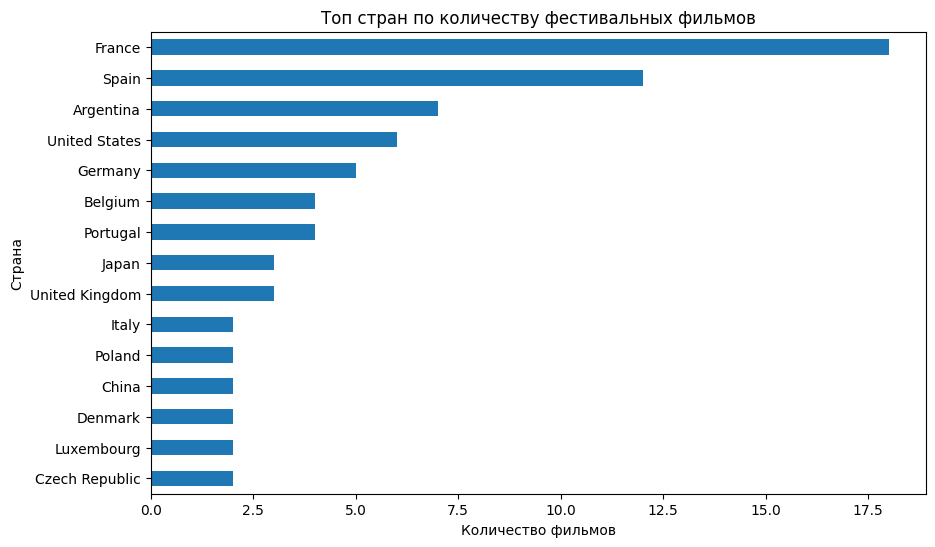

In [184]:
plt.figure(figsize=(10, 6))

country_counts.sort_values().plot(kind="barh")

plt.title("Топ стран по количеству фестивальных фильмов")
plt.xlabel("Количество фильмов")
plt.ylabel("Страна")

plt.show()